<a href="https://colab.research.google.com/github/JesiyaFernandes/heartattackrisk/blob/main/Copy_of_riskprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import pandas as pd

json_path = "/content/drive/MyDrive/Data_Set_China/data_info.json"   # update path
csv_path  = "/content/drive/MyDrive/Data_Set_China/data_csv.csv"

with open(json_path, "r", encoding="utf-8") as f:
    raw = json.load(f)   # raw is a dict: { "2491006": { ... }, "3730004": { ... }, ... }

rows = []

for patient_id, info in raw.items():
    # common fields
    gender    = info.get("gender")
    thickness = info.get("thickness")
    label     = info.get("label")   # 0/1 – this is your risk label
    group     = info.get("group")
    true_age  = info.get("True_age")
    age_norm  = info.get("age")     # normalized age if present

    # right eye
    if "right_eye" in info and info["right_eye"]:
        rows.append({
            "PatientID": patient_id,
            "eye": "R",
            "filename": info["right_eye"],
            "gender": gender,
            "thickness": thickness,
            "label": label,
            "group": group,
            "True_age": true_age,
            "age_norm": age_norm,
        })

    # left eye
    if "left_eye" in info and info["left_eye"]:
        rows.append({
            "PatientID": patient_id,
            "eye": "L",
            "filename": info["left_eye"],
            "gender": gender,
            "thickness": thickness,
            "label": label,
            "group": group,
            "True_age": true_age,
            "age_norm": age_norm,
        })

# Create DataFrame and save to CSV
df = pd.DataFrame(rows)
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)
print(df.head())


Saved: /content/drive/MyDrive/Data_Set_China/data_csv.csv
  PatientID eye       filename  gender  thickness  label  group  True_age  \
0   2491006   R  2491006_R.png       0        0.8      0      1        63   
1   2491006   L  2491006_L.png       0        0.8      0      1        63   
2   3730004   R  3730004_R.png       1        1.2      1      1        61   
3   3730004   L  3730004_L.png       1        1.2      1      1        61   
4   3730006   R  3730006_R.png       1        1.2      1      1        64   

   age_norm  
0  0.684932  
1  0.684932  
2  0.657534  
3  0.657534  
4  0.698630  


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
"""
Preprocessing pipeline for retinal fundus dataset
- CSV cleaning and encoding
- Patient-level train/val/test split
- Image cropping, resizing, and normalization-ready storage

Author: <your name>
"""

import os
from pathlib import Path
import shutil
import random

import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------
# Configuration
# -----------------------------
DATA_ROOT = Path("/content/drive/MyDrive/Data_Set_China/Fundus_CIMT_2903_cropped_512")  # folder containing images
CSV_PATH = Path("/content/drive/MyDrive/Data_Set_China/data_csv.csv")               # your CSV file
OUTPUT_ROOT = Path("/content/drive/MyDrive/Data_Set_China/processed_dataset")

IMAGE_EXT = ".png"
IMAGE_SIZE = 384              # final square size (e.g. 224, 299, 384)
RANDOM_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15              # test will be 1 - TRAIN_RATIO - VAL_RATIO

# Column names in your CSV (adjust if different)
COL_PATIENT_ID = "PatientID"
COL_FILENAME = "filename"
COL_EYE = "eye"               # 'L' or 'R'
COL_GENDER = "gender"         # 0/1 or M/F
COL_LABEL = "label"           # risk label
COL_GROUP = "group"           # optional extra grouping

# -----------------------------
# Utility functions
# -----------------------------

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

def load_and_clean_csv(csv_path: Path) -> pd.DataFrame:
    """Load CSV, drop duplicates/NA, standardize dtypes, and attach image paths."""
    df = pd.read_csv(csv_path)

    # Basic cleaning
    df = df.drop_duplicates()
    df = df.dropna(subset=[COL_PATIENT_ID, COL_FILENAME])

    # Ensure types
    df[COL_PATIENT_ID] = df[COL_PATIENT_ID].astype(str)
    df[COL_FILENAME] = df[COL_FILENAME].astype(str)

    # Standardize eye column if present
    if COL_EYE in df.columns:
        df[COL_EYE] = df[COL_EYE].str.upper().str.strip()

    # Encode gender if text; if already 0/1, this will have no effect
    if COL_GENDER in df.columns and not np.issubdtype(df[COL_GENDER].dtype, np.number):
        df[COL_GENDER] = (
            df[COL_GENDER]
            .str.upper()
            .str.strip()
            .map({"M": 1, "MALE": 1, "F": 0, "FEMALE": 0})
        )

    # Attach full image path
    df["image_path"] = df[COL_FILENAME].apply(
        lambda x: str(DATA_ROOT / x)
    )

    # Filter rows where image file actually exists
    df["image_exists"] = df["image_path"].apply(os.path.exists)
    missing = df[~df["image_exists"]]
    if len(missing) > 0:
        print(f"Warning: {len(missing)} entries without images will be dropped.")
        df = df[df["image_exists"]]

    df = df.drop(columns=["image_exists"])

    return df


def crop_fundus_circle(img: np.ndarray, padding: int = 10) -> np.ndarray:
    """
    Simple cropping of fundus images:
    - Convert to gray
    - Threshold to find the circular fundus region
    - Crop to bounding box with small padding.
    Inspired by common fundus pre-processing approaches. [web:23][web:27][web:28]
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Normalize and threshold
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(gray_blur, 10, 255, cv2.THRESH_BINARY)

    # Find bounding box of the non-zero region
    coords = cv2.findNonZero(mask)
    if coords is None:
        return img  # fallback: return original

    x, y, w, h = cv2.boundingRect(coords)

    x0 = max(x - padding, 0)
    y0 = max(y - padding, 0)
    x1 = min(x + w + padding, img.shape[1])
    y1 = min(y + h + padding, img.shape[0])

    cropped = img[y0:y1, x0:x1]
    return cropped


def preprocess_image(path: str, image_size: int = 384) -> np.ndarray:
    """
    Load an image from disk, crop border, resize to fixed size.
    Returns BGR uint8 image; normalization will typically be done in the
    dataloader before feeding into the network. [web:28][web:31][web:37]
    """
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")

    img = crop_fundus_circle(img, padding=10)
    img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_AREA)

    return img


def patient_level_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split dataframe into train/val/test at patient level to avoid leakage. [web:29][web:32][web:35][web:41]
    """
    patients = df[COL_PATIENT_ID].unique()
    train_patients, temp_patients = train_test_split(
        patients, test_size=(1 - TRAIN_RATIO), random_state=RANDOM_SEED, shuffle=True
    )

    val_size_rel = VAL_RATIO / (1 - TRAIN_RATIO)
    val_patients, test_patients = train_test_split(
        temp_patients, test_size=(1 - val_size_rel), random_state=RANDOM_SEED, shuffle=True
    )

    train_df = df[df[COL_PATIENT_ID].isin(train_patients)].reset_index(drop=True)
    val_df = df[df[COL_PATIENT_ID].isin(val_patients)].reset_index(drop=True)
    test_df = df[df[COL_PATIENT_ID].isin(test_patients)].reset_index(drop=True)

    print(f"Patients: train={len(train_patients)}, val={len(val_patients)}, test={len(test_patients)}")
    print(f"Images:   train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

    return train_df, val_df, test_df


def save_split_and_images(
    df: pd.DataFrame,
    split_name: str,
    output_root: Path,
    image_size: int = 384,
    limit: int | None = None,
):
    """
    Preprocess and copy images into structured folders:
        output_root/split_name/images/
    Also save the CSV with updated relative paths.
    """
    split_root = output_root / split_name
    img_out_dir = split_root / "images"
    split_root.mkdir(parents=True, exist_ok=True)
    img_out_dir.mkdir(parents=True, exist_ok=True)

    processed_paths = []
    rows = df if limit is None else df.iloc[:limit].copy()

    for idx, row in rows.iterrows():
        src = row["image_path"]
        # Preserve filename
        fname = os.path.basename(src)
        dst = img_out_dir / fname

        try:
            img = preprocess_image(src, image_size=image_size)
            cv2.imwrite(str(dst), img)
            processed_paths.append(str(dst.relative_to(split_root)))
        except Exception as e:
            print(f"[{split_name}] Skipping {src}: {e}")
            processed_paths.append(None)

    rows["processed_path"] = processed_paths
    rows = rows.dropna(subset=["processed_path"])

    # Save CSV for this split
    csv_out = split_root / f"{split_name}_metadata.csv"
    rows.to_csv(csv_out, index=False)
    print(f"Saved {len(rows)} records for {split_name} to {csv_out}")


# -----------------------------
# Main entrypoint
# -----------------------------
if __name__ == "__main__":
    set_seed(RANDOM_SEED)

    # 1. Load & clean CSV
    df_all = load_and_clean_csv(CSV_PATH)
    print(f"Total valid rows after cleaning: {len(df_all)}")

    # 2. Optional: basic sanity checks
    if COL_LABEL in df_all.columns:
        print("Label distribution:")
        print(df_all[COL_LABEL].value_counts(dropna=False))

    # 3. Patient-level split
    train_df, val_df, test_df = patient_level_split(df_all)

    # 4. Save splits and preprocessed images
    #    Remove `limit` argument to process the full dataset.
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    save_split_and_images(train_df, "train", OUTPUT_ROOT, image_size=IMAGE_SIZE)
    save_split_and_images(val_df, "val", OUTPUT_ROOT, image_size=IMAGE_SIZE)
    save_split_and_images(test_df, "test", OUTPUT_ROOT, image_size=IMAGE_SIZE)

    print("Preprocessing completed.")


Total valid rows after cleaning: 5806
Label distribution:
label
1    4108
0    1698
Name: count, dtype: int64
Patients: train=2032, val=435, test=436
Images:   train=4064, val=870, test=872
Saved 4064 records for train to /content/drive/MyDrive/Data_Set_China/processed_dataset/train/train_metadata.csv
Saved 870 records for val to /content/drive/MyDrive/Data_Set_China/processed_dataset/val/val_metadata.csv
Saved 872 records for test to /content/drive/MyDrive/Data_Set_China/processed_dataset/test/test_metadata.csv
Preprocessing completed.


In [ ]:
#feature extraction
''' This cell then takes those pre-split
images from the processed_dataset/{split}/images
folders and extracts deep learning features for each split,
saving them as train_features.npy, val_features.npy, etc.'''
'''This cell uses a pre-trained EfficientNet-B3 model (initialized with ImageNet weights)
to extract deep learning features from the fundus images. It doesn't
 train the EfficientNet-B3; it simply leverages its learned representations
  by removing its classification head and using its convolutional layers to
   generate 1536-dimensional feature vectors.'''
import os
from pathlib import Path
import numpy as np
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

import cv2

# -----------------------------
# Configuration
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Fix: Added missing '/' in the path
PROCESSED_ROOT = Path("/content/drive/MyDrive/Data_Set_China/processed_dataset")
BATCH_SIZE = 32
NUM_WORKERS = 2
IMAGE_SIZE = 300
FEATURE_DIM = 1536  # EfficientNet-B3 last conv feature size

# -----------------------------
# Dataset and transforms
# -----------------------------

class FundusImageOnlyDataset(Dataset):
    def __init__(self, images_dir: Path, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.image_paths = sorted([
            p for p in images_dir.glob("*")
            if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(img)

        return img, str(path.name)

# ImageNet normalization for pretrained EfficientNet. [web:30][web:62]
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# -----------------------------
# Feature extractor model
# -----------------------------

def build_feature_extractor():
    """
    EfficientNet-B3 pretrained on ImageNet, used only as feature extractor
    (classifier head removed).
    """
    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
    model = efficientnet_b3(weights=weights)
    model.classifier = nn.Identity()
    model.eval()
    return model.to(DEVICE)


# -----------------------------
# Extraction loop
# -----------------------------

def extract_features_from_folder(split_name: str):
    images_dir = PROCESSED_ROOT / split_name / "images"
    dataset = FundusImageOnlyDataset(images_dir, transform=image_transform)
    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model = build_feature_extractor()

    all_features = []
    all_filenames = []

    with torch.no_grad():
        for imgs, names in tqdm(dataloader, desc=f"{split_name} feature extraction"):
            imgs = imgs.to(DEVICE, non_blocking=True)
            feats = model(imgs)               # (B, FEATURE_DIM)
            feats = feats.cpu().numpy()

            all_features.append(feats)
            all_filenames.extend(names)

    # Only concatenate if there are features to avoid ValueError
    if len(all_features) > 0:
        all_features = np.concatenate(all_features, axis=0)
    else:
        print(f"Warning: No features extracted for {split_name}. Check image_dir: {images_dir}")
        all_features = np.array([]) # Ensure it's an empty numpy array

    # Save
    split_root = PROCESSED_ROOT / split_name
    split_root.mkdir(parents=True, exist_ok=True)

    feat_path = split_root / f"{split_name}_features.npy"
    names_path = split_root / f"{split_name}_filenames.npy"

    if all_features.size > 0:
        np.save(feat_path, all_features)
        np.save(names_path, np.array(all_filenames))
    else:
        print(f"Skipping save for {split_name} as no features were extracted.")

    print(f"{split_name}: features shape = {all_features.shape}")
    print(f"Saved features to {feat_path}")
    print(f"Saved filenames to {names_path}")


if __name__ == "__main__":
    for split in ["train", "val", "test"]:
        extract_features_from_folder(split)
    print("Done.")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 196MB/s]
train feature extraction: 100%|██████████| 127/127 [02:03<00:00,  1.03it/s]


train: features shape = (4064, 1536)
Saved features to /content/drive/MyDrive/Data_Set_China/processed_dataset/train/train_features.npy
Saved filenames to /content/drive/MyDrive/Data_Set_China/processed_dataset/train/train_filenames.npy


val feature extraction: 100%|██████████| 28/28 [00:29<00:00,  1.06s/it]


val: features shape = (870, 1536)
Saved features to /content/drive/MyDrive/Data_Set_China/processed_dataset/val/val_features.npy
Saved filenames to /content/drive/MyDrive/Data_Set_China/processed_dataset/val/val_filenames.npy


test feature extraction: 100%|██████████| 28/28 [00:43<00:00,  1.56s/it]


test: features shape = (872, 1536)
Saved features to /content/drive/MyDrive/Data_Set_China/processed_dataset/test/test_features.npy
Saved filenames to /content/drive/MyDrive/Data_Set_China/processed_dataset/test/test_filenames.npy
Done.


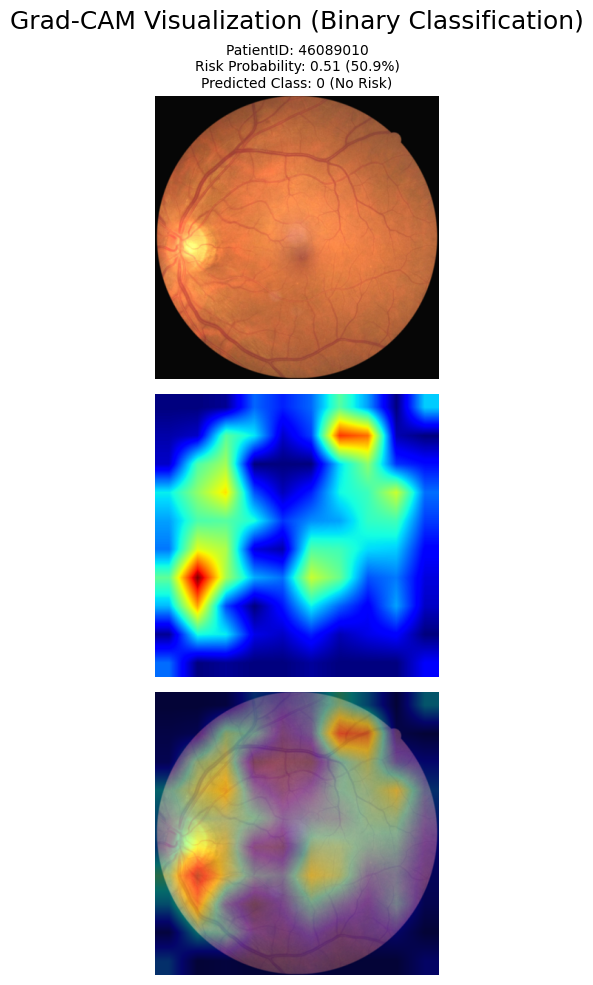

✅ Binary Grad-CAM figure saved as binary_gradcam_paper_style.png


In [ ]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import numpy as np

# ------------------------------
# CONFIG
# ------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROCESSED_ROOT = Path("/content/drive/MyDrive/Data_Set_China/processed_dataset")
IMAGE_SIZE = 300
class_names = ["No Risk", "High Risk"]  # Change if needed

# ------------------------------
# TRANSFORM
# ------------------------------
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ------------------------------
# BUILD BINARY MODEL (2 OUTPUTS)
# ------------------------------
def build_model():
    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
    model = efficientnet_b3(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    return model.to(DEVICE)

model = build_model()
model.eval()

# ✅ If you have trained weights, load them here:
# model.load_state_dict(torch.load("your_model.pth", map_location=DEVICE, weights_only=False))

# ------------------------------
# GRADCAM CLASS
# ------------------------------
class GradCAM:
    def __init__(self, model, target_layer_name='features.8'):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer = dict(model.named_modules())[target_layer_name]
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, img_tensor):
        self.model.zero_grad()
        output = self.model(img_tensor)

        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1)
        confidence = probs[0, pred_class].item()

        score = output[:, pred_class]
        score.backward()

        weights = torch.mean(self.gradients, dim=[2,3], keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)
        cam = F.relu(cam)
        cam = cam.squeeze()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu(), pred_class.item(), confidence

gradcam = GradCAM(model)

# ------------------------------
# LOAD TEST IMAGES (SELECTIVE)
# ------------------------------
test_dir = PROCESSED_ROOT / "test" / "images"

# ==================================================================
# USER INPUT: List specific image filenames for Grad-CAM.
# If empty, the first 4 images from the test set will be used.
user_selected_filenames = ["47091003_L.png" , "46089010_L.png"]  # Example: ["2491006_R.png", "3730004_L.png"]
# ==================================================================

if user_selected_filenames:
    test_images = []
    for fname in user_selected_filenames:
        img_path = test_dir / fname
        if img_path.exists():
            test_images.append(img_path)
        else:
            print(f"Warning: Selected image '{fname}' not found in {test_dir}. Skipping.")
else:
    # Default to first 4 images if no specific images are selected
    test_images = list(test_dir.glob("*.png"))[:4]

# Add a check for empty test_images list after selection
if not test_images:
    print(f"Error: No images found to process in {test_dir} or your selected filenames were not found.")
    print("Please ensure the preprocessing cell was run correctly and image files exist.")
else:
    # ------------------------------
    # PLOT PAPER STYLE (3 ROWS)
    # ------------------------------
    fig, axs = plt.subplots(3, len(test_images), figsize=(18, 10), squeeze=False) # FIX: Added squeeze=False

    for col, img_path in enumerate(test_images):

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = image_transform(img).unsqueeze(0).to(DEVICE)

        cam, pred_class, confidence = gradcam.generate(img_tensor)

        cam_resized = cv2.resize(cam.numpy(), (img.shape[1], img.shape[0]))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

        # Row A - Original
        axs[0, col].imshow(img)
        # Extract PatientID from filename (e.g., "2491006_R.png" -> "2491006")
        patient_id = img_path.stem.split('_')[0]
        # Update title to match graddd.png format with PatientID
        title_text = f"PatientID: {patient_id}\nRisk Probability: {confidence:.2f} ({confidence:.1%})\nPredicted Class: {pred_class} ({class_names[pred_class]})"
        axs[0, col].set_title(title_text, fontsize=10) # Adjusted fontsize
        axs[0, col].axis("off")
        if col == 0:
            axs[0, col].set_ylabel("(A) Original Image\n& Prediction", fontsize=12)

        # Row B - Heatmap
        axs[1, col].imshow(cam_resized, cmap='jet')
        axs[1, col].axis("off")
        if col == 0:
            axs[1, col].set_ylabel("(B) Heatmap", fontsize=12)

        # Row C - Overlay
        axs[2, col].imshow(overlay)
        axs[2, col].axis("off")
        if col == 0:
            axs[2, col].set_ylabel("(C) Overlay", fontsize=12)

    plt.suptitle("Grad-CAM Visualization (Binary Classification)", fontsize=18)
    plt.tight_layout()
    plt.savefig("binary_gradcam_paper_style.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Binary Grad-CAM figure saved as binary_gradcam_paper_style.png")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 120MB/s]


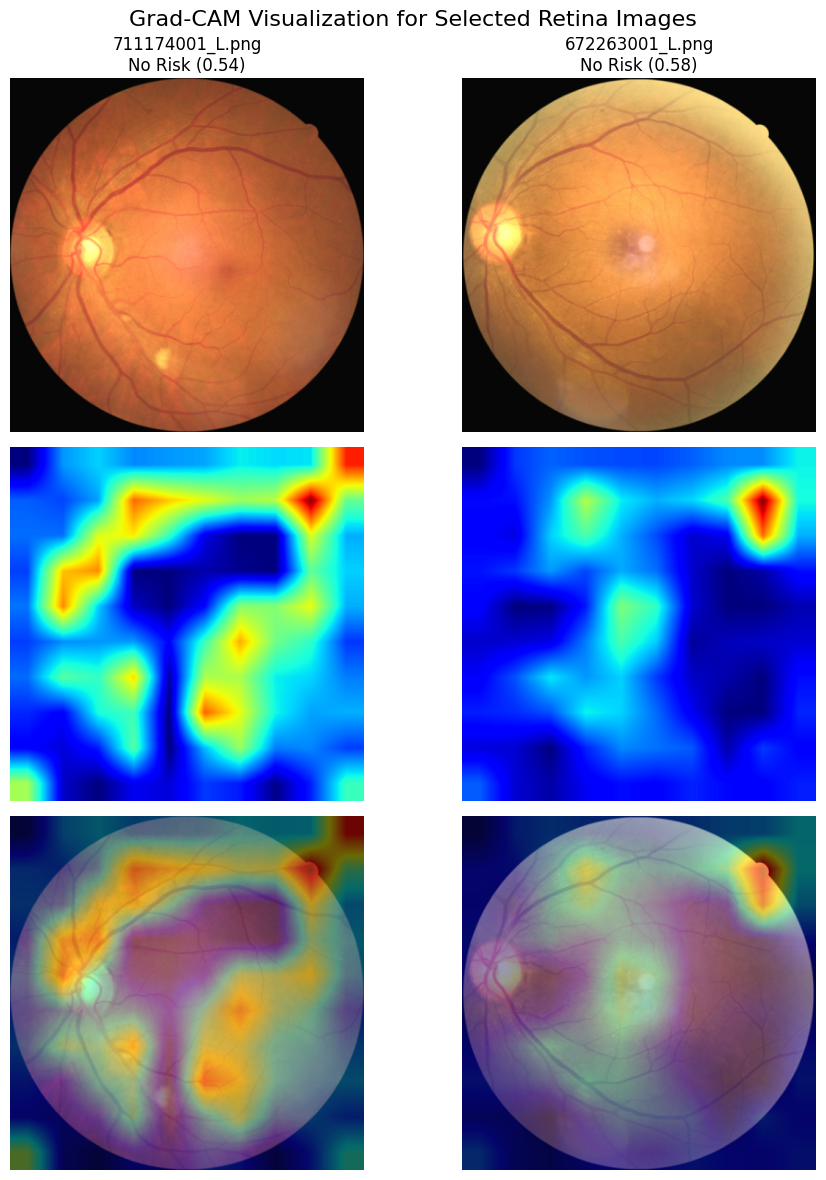

✅ Grad-CAM figure generated for 2 selected images! Saved to: /content/drive/MyDrive/Data_Set_China/B3/selected_2_gradcam.png


In [ ]:
# ==============================
# GRADCAM FOR SPECIFIC 2 IMAGES
# ==============================

import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import numpy as np

# ------------------------------
# CONFIG
# ------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROCESSED_ROOT = Path("/content/drive/MyDrive/Data_Set_China/processed_dataset")
IMAGE_SIZE = 300
class_names = ["No Risk", "High Risk"]  # Change if needed
OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/B3") # User-specified output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # Ensure directory exists

# ------------------------------
# SELECT YOUR 2 IMAGE FILENAMES HERE
# ------------------------------
selected_images = [
    "711174001_L.png",
    "672263001_L.png"
]

# ------------------------------
# TRANSFORM
# ------------------------------
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ------------------------------
# BUILD MODEL (2 OUTPUTS)
# ------------------------------
def build_model():
    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
    model = efficientnet_b3(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    return model.to(DEVICE)

model = build_model()
model.eval()

# ⚠️ Load trained weights here if available
# model.load_state_dict(torch.load("your_model.pth", map_location=DEVICE))

# ------------------------------
# GRADCAM CLASS
# ------------------------------
class GradCAM:
    def __init__(self, model, target_layer_name='features.8'):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer = dict(model.named_modules())[target_layer_name]
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, img_tensor):
        self.model.zero_grad()
        output = self.model(img_tensor)

        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1)
        confidence = probs[0, pred_class].item()

        score = output[:, pred_class]
        score.backward()

        weights = torch.mean(self.gradients, dim=[2,3], keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)
        cam = F.relu(cam)
        cam = cam.squeeze()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu(), pred_class.item(), confidence

gradcam = GradCAM(model)

# ------------------------------
# CREATE FIGURE (3 ROWS, 2 COLS)
# ------------------------------
fig, axs = plt.subplots(3, 2, figsize=(10, 12))

for col, img_name in enumerate(selected_images):

    img_path = PROCESSED_ROOT / "test" / "images" / img_name

    # Check if image file exists and can be read
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Warning: Image '{img_name}' not found or unreadable at {img_path}. Skipping.")
        # Fill the subplot with a placeholder if image is missing to maintain layout
        axs[0, col].text(0.5, 0.5, 'Image Not Found', horizontalalignment='center', verticalalignment='center', transform=axs[0, col].transAxes)
        axs[0, col].axis('off')
        axs[1, col].axis('off')
        axs[2, col].axis('off')
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_tensor = image_transform(img).unsqueeze(0).to(DEVICE)

    cam, pred_class, confidence = gradcam.generate(img_tensor)

    cam_resized = cv2.resize(cam.numpy(), (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # (A) Original
    axs[0, col].imshow(img)
    axs[0, col].set_title(f"{img_name}\n{class_names[pred_class]} ({confidence:.2f})")
    axs[0, col].axis("off")
    if col == 0:
        axs[0, col].set_ylabel("(A)", fontsize=14)

    # (B) Heatmap
    axs[1, col].imshow(cam_resized, cmap='jet')
    axs[1, col].axis("off")
    if col == 0:
        axs[1, col].set_ylabel("(B)", fontsize=14)

    # (C) Overlay
    axs[2, col].imshow(overlay)
    axs[2, col].axis("off")
    if col == 0:
        axs[2, col].set_ylabel("(C)", fontsize=14)

plt.suptitle("Grad-CAM Visualization for Selected Retina Images", fontsize=16)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "selected_2_gradcam.png", dpi=300, bbox_inches='tight') # Save to OUTPUT_DIR
plt.show()

print(f"✅ Grad-CAM figure generated for 2 selected images! Saved to: {OUTPUT_DIR / 'selected_2_gradcam.png'}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#making raw clinical csv and normalizing it for multi-modal model training
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
CSV_PATH = Path("/content/drive/MyDrive/Data_Set_China/data_csv.csv")
OUT_CSV_PATH = Path("/content/drive/MyDrive/Data_Set_China/data_csv_normalized.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
NUM_EPOCHS = 30
LR = 1e-3
LATENT_DIM = 8  # 8D normalized features for B3 pipeline

NUM_COLS = ["gender", "thickness", "True_age", "age_norm"]

# -----------------------------
# Dataset (unchanged)
# -----------------------------
class TabularFeatureDataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = x.astype(np.float32)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx]

# -----------------------------
# FC autoencoder normalizer (unchanged)
# -----------------------------
class TabularNormalizer(nn.Module):
    def __init__(self, in_dim: int, latent_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return z, recon

# -----------------------------
# Main (FIXED)
# -----------------------------
if __name__ == "__main__":
    # 1) Load CSV and extract numeric features
    df = pd.read_csv(CSV_PATH)
    x = df[NUM_COLS].values
    in_dim = x.shape[1]
    print(f"Input shape: {x.shape} | Features: {NUM_COLS}")

    dataset = TabularFeatureDataset(x)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 2) Train normalizer (autoencoder)
    model = TabularNormalizer(in_dim, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    model.train()
    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        for batch in loader:
            batch = batch.to(DEVICE)
            z, recon = model(batch)
            loss = criterion(recon, batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch.size(0)

        epoch_loss /= len(dataset)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, recon MSE: {epoch_loss:.6f}")

    # 3) Get normalized features for all rows (MOVED OUTSIDE LOOP)
    print("\n🔄 Encoding all rows...")
    full_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    all_z = []

    with torch.no_grad():
        for batch in tqdm(full_loader, desc="Encoding all rows"):
            batch = batch.to(DEVICE)
            z, _ = model(batch)
            all_z.append(z.cpu().numpy())

    all_z = np.concatenate(all_z, axis=0)
    print(f"✅ Encoded shape: {all_z.shape}")


    # 4) Save back to CSV
    for i in range(LATENT_DIM):
        df[f"f{i}"] = all_z[:, i]

    df.to_csv(OUT_CSV_PATH, index=False)
    print(f"✅ Saved {LATENT_DIM}D normalized features to {OUT_CSV_PATH}")
    print(f"📊 New columns: f0-f{LATENT_DIM-1}")
    print("🎯 Ready for B3 multi-modal training!")


Input shape: (5806, 4) | Features: ['gender', 'thickness', 'True_age', 'age_norm']
Epoch 1/30, recon MSE: 606.109977
Epoch 2/30, recon MSE: 585.939873
Epoch 3/30, recon MSE: 545.608877
Epoch 4/30, recon MSE: 465.261154
Epoch 5/30, recon MSE: 328.602841
Epoch 6/30, recon MSE: 178.734336
Epoch 7/30, recon MSE: 107.538995
Epoch 8/30, recon MSE: 75.560299
Epoch 9/30, recon MSE: 50.736683
Epoch 10/30, recon MSE: 34.177194
Epoch 11/30, recon MSE: 24.918107
Epoch 12/30, recon MSE: 19.526334
Epoch 13/30, recon MSE: 16.924198
Epoch 14/30, recon MSE: 14.148971
Epoch 15/30, recon MSE: 12.151069
Epoch 16/30, recon MSE: 9.350053
Epoch 17/30, recon MSE: 7.838603
Epoch 18/30, recon MSE: 6.755200
Epoch 19/30, recon MSE: 5.691564
Epoch 20/30, recon MSE: 4.652418
Epoch 21/30, recon MSE: 4.505394
Epoch 22/30, recon MSE: 3.513173
Epoch 23/30, recon MSE: 2.924841
Epoch 24/30, recon MSE: 2.811983
Epoch 25/30, recon MSE: 2.355570
Epoch 26/30, recon MSE: 1.871168
Epoch 27/30, recon MSE: 2.159528
Epoch 28/30, 

Encoding all rows: 100%|██████████| 23/23 [00:00<00:00, 667.86it/s]

✅ Encoded shape: (5806, 8)
✅ Saved 8D normalized features to /content/drive/MyDrive/Data_Set_China/data_csv_normalized.csv
📊 New columns: f0-f7
🎯 Ready for B3 multi-modal training!


In [ ]:
!pip install lion-pytorch


In [ ]:
#this part is responsible for gathering (load_split)all the necessary processed data image+clinical data
#then prepares it for multimodal fusion classifier
'''(Multi-modal Fusion): This cell loads those already
split and feature-extracted data (train_features.npy, val_features.npy, etc.)
and combines them with clinical data for final model training.'''
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score


# -----------------------------
# Paths and config (B3 Updated)
# -----------------------------
BASE = Path("/content/drive/MyDrive/Data_Set_China/processed_dataset")  # Fixed path


TRAIN_FEATS = BASE / "train" / "train_features.npy"
TRAIN_NAMES = BASE / "train" / "train_filenames.npy"
VAL_FEATS   = BASE / "val" / "val_features.npy"
VAL_NAMES   = BASE / "val" / "val_filenames.npy"
TEST_FEATS  = BASE / "test" / "test_features.npy"
TEST_NAMES  = BASE / "test" / "test_filenames.npy"


CLIN_CSV = Path("/content/drive/MyDrive/Data_Set_China/data_csv_normalized.csv")


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 50


# ✅ B3 SPECIFIC:
IMAGE_FEAT_DIM = 1536  # B3 (was 1280 for B0)
CLIN_FEAT_COLS = ['gender', 'thickness', 'True_age', 'age_norm'] + [f"f{i}" for i in range(8)]
FUSED_DIM = IMAGE_FEAT_DIM + len(CLIN_FEAT_COLS)  # 1536 + 12 = 1548D



DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 30
IMAGE_FEAT_DIM = 1536
CLIN_FEAT_COLS = ['gender', 'thickness', 'True_age', 'age_norm'] + [f"f{i}" for i in range(8)]
FUSED_DIM = IMAGE_FEAT_DIM + len(CLIN_FEAT_COLS)


# Define output directory for saving model and plots
OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3")


# -----------------------------
# Data preparation
# -----------------------------
def load_split(
    feat_path: Path,
    name_path: Path,
    clin_df: pd.DataFrame
) -> Tuple[np.ndarray, np.ndarray]:
    """
    For one split, align image features and clinical features via filename,
    then return fused features and labels.
    """
    img_feats = np.load(feat_path)  # (N, 1280)
    filenames = np.load(name_path)  # (N,)

    # Map filename -> row in clinical CSV
    clin_sub = clin_df.set_index("filename").loc[filenames]
    clin_feats = clin_sub[CLIN_FEAT_COLS].values.astype(np.float32)  # (N, 8)
    labels = clin_sub["label"].values.astype(np.int64)              # (N,)

    # Concatenate image + clinical latent features
    fused = np.concatenate([img_feats.astype(np.float32), clin_feats], axis=1)

    assert fused.shape[0] == labels.shape[0]
    return fused, labels


class FusionDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# -----------------------------
# Model
# -----------------------------
class FusionClassifier(nn.Module):
    """
    Simple fully connected classifier on fused features.
    """
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1),         # binary classification
        )

    def forward(self, x):
        logits = self.net(x)
        return logits.view(-1)


# -----------------------------
# Training & evaluation loops
# -----------------------------
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_targets, all_probs = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb.float())

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_targets.append(yb.cpu().numpy())

    total_loss /= len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_targets, preds)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auc = float("nan")

    return total_loss, acc, auc


# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    # 1. Load clinical CSV
    clin_df = pd.read_csv(CLIN_CSV)

    # 2. Build fused features for each split
    x_train, y_train = load_split(TRAIN_FEATS, TRAIN_NAMES, clin_df)
    x_val,   y_val   = load_split(VAL_FEATS,   VAL_NAMES,   clin_df)
    x_test,  y_test  = load_split(TEST_FEATS,  TEST_NAMES,  clin_df)

    print("Train fused:", x_train.shape, "Val fused:", x_val.shape, "Test fused:", x_test.shape)


    train_ds = FusionDataset(x_train, y_train)
    val_ds   = FusionDataset(x_val,   y_val)
    test_ds  = FusionDataset(x_test,  y_test)


    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


    # REPLACE lines 158-160 with THESE 3 lines:
    model = FusionClassifier(FUSED_DIM).to(DEVICE)
    pos_weight = torch.tensor([np.sum(y_train==0) / np.sum(y_train==1)]).to(DEVICE) # Use calculated pos_weight
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)



    best_val_auc = 0.0
    best_state = None


    # 4. Training loop
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, train_auc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_auc = run_epoch(model, val_loader, criterion, optimizer=None)


        print(
            f"Epoch {epoch:02d} | "
            f"Train loss {train_loss:.4f}, acc {train_acc:.3f}, AUC {train_auc:.3f} | "
            f"Val loss {val_loss:.4f}, acc {val_acc:.3f}, AUC {val_auc:.3f}"
        )


        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict().copy()


    # Save the best model after training
    if best_state is not None:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        checkpoint_path = OUTPUT_DIR / "best_model.pth"
        torch.save({"model_state": best_state}, checkpoint_path)
        print(f"Saved best model to {checkpoint_path}")


    # 5. Test evaluation using best model
    if best_state is not None:
        model.load_state_dict(best_state)


    test_loss, test_acc, test_auc = run_epoch(model, test_loader, criterion, optimizer=None)
    print(f"TEST | loss {test_loss:.4f}, acc {test_acc:.3f}, AUC {test_auc:.3f}")

Train fused: (4064, 1548) Val fused: (870, 1548) Test fused: (872, 1548)
Epoch 01 | Train loss 0.2752, acc 0.783, AUC 0.869 | Val loss 0.2942, acc 0.694, AUC 0.903
Epoch 02 | Train loss 0.1779, acc 0.870, AUC 0.950 | Val loss 0.1528, acc 0.882, AUC 0.965
Epoch 03 | Train loss 0.1177, acc 0.917, AUC 0.978 | Val loss 0.3507, acc 0.638, AUC 0.972
Epoch 04 | Train loss 0.0848, acc 0.943, AUC 0.989 | Val loss 0.0941, acc 0.914, AUC 0.988
Epoch 05 | Train loss 0.0690, acc 0.951, AUC 0.992 | Val loss 0.2101, acc 0.818, AUC 0.969
Epoch 06 | Train loss 0.0646, acc 0.958, AUC 0.993 | Val loss 0.2317, acc 0.789, AUC 0.981
Epoch 07 | Train loss 0.0529, acc 0.964, AUC 0.995 | Val loss 0.2717, acc 0.885, AUC 0.982
Epoch 08 | Train loss 0.0543, acc 0.962, AUC 0.995 | Val loss 0.0900, acc 0.929, AUC 0.986
Epoch 09 | Train loss 0.0579, acc 0.961, AUC 0.994 | Val loss 0.1707, acc 0.932, AUC 0.975
Epoch 10 | Train loss 0.0396, acc 0.973, AUC 0.997 | Val loss 0.0714, acc 0.952, AUC 0.991
Epoch 11 | Train 

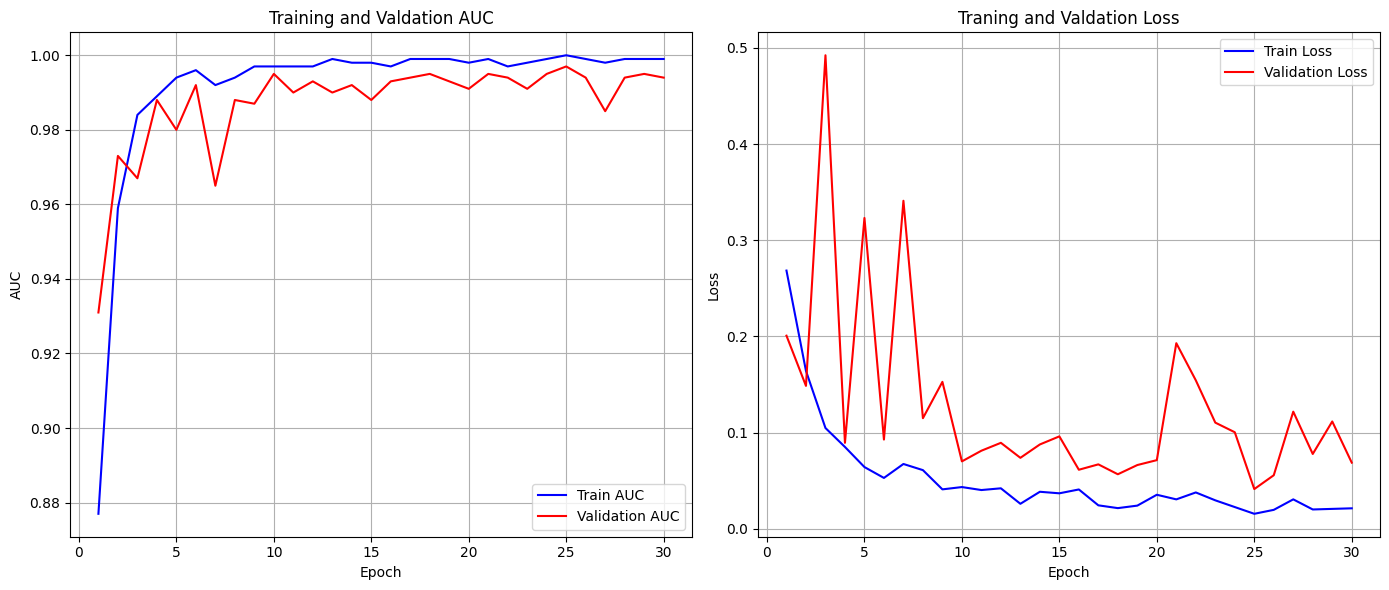

Saved AUC and Loss plots for Adam optimizer to /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/adam_metrics_auc_loss.png


In [ ]:
import matplotlib.pyplot as plt
import re
import pandas as pd
from pathlib import Path

# Adam Optimizer log output (from RNIefPhz6Hbm)
adam_log_output = """
Train fused: (4064, 1548) Val fused: (870, 1548) Test fused: (872, 1548)
Epoch 01 | Train loss 0.2684, acc 0.799, AUC 0.877 | Val loss 0.2007, acc 0.853, AUC 0.931
Epoch 02 | Train loss 0.1641, acc 0.883, AUC 0.959 | Val loss 0.1485, acc 0.922, AUC 0.973
Epoch 03 | Train loss 0.1047, acc 0.931, AUC 0.984 | Val loss 0.4923, acc 0.807, AUC 0.967
Epoch 04 | Train loss 0.0850, acc 0.942, AUC 0.989 | Val loss 0.0893, acc 0.929, AUC 0.988
Epoch 05 | Train loss 0.0641, acc 0.954, AUC 0.994 | Val loss 0.3231, acc 0.871, AUC 0.980
Epoch 06 | Train loss 0.0528, acc 0.966, AUC 0.996 | Val loss 0.0927, acc 0.952, AUC 0.992
Epoch 07 | Train loss 0.0673, acc 0.954, AUC 0.992 | Val loss 0.3410, acc 0.884, AUC 0.965
Epoch 08 | Train loss 0.0609, acc 0.958, AUC 0.994 | Val loss 0.1149, acc 0.947, AUC 0.988
Epoch 09 | Train loss 0.0409, acc 0.975, AUC 0.997 | Val loss 0.1527, acc 0.930, AUC 0.987
Epoch 10 | Train loss 0.0433, acc 0.973, AUC 0.997 | Val loss 0.0700, acc 0.939, AUC 0.995
Epoch 11 | Train loss 0.0402, acc 0.972, AUC 0.997 | Val loss 0.0811, acc 0.955, AUC 0.990
Epoch 12 | Train loss 0.0420, acc 0.971, AUC 0.997 | Val loss 0.0893, acc 0.918, AUC 0.993
Epoch 13 | Train loss 0.0259, acc 0.984, AUC 0.999 | Val loss 0.0737, acc 0.944, AUC 0.990
Epoch 14 | Train loss 0.0384, acc 0.973, AUC 0.998 | Val loss 0.0876, acc 0.923, AUC 0.992
Epoch 15 | Train loss 0.0368, acc 0.976, AUC 0.998 | Val loss 0.0960, acc 0.945, AUC 0.988
Epoch 16 | Train loss 0.0408, acc 0.967, AUC 0.997 | Val loss 0.0613, acc 0.948, AUC 0.993
Epoch 17 | Train loss 0.0243, acc 0.983, AUC 0.999 | Val loss 0.0669, acc 0.961, AUC 0.994
Epoch 18 | Train loss 0.0214, acc 0.986, AUC 0.999 | Val loss 0.0566, acc 0.954, AUC 0.995
Epoch 19 | Train loss 0.0240, acc 0.985, AUC 0.999 | Val loss 0.0662, acc 0.946, AUC 0.993
Epoch 20 | Train loss 0.0353, acc 0.978, AUC 0.998 | Val loss 0.0713, acc 0.953, AUC 0.991
Epoch 21 | Train loss 0.0305, acc 0.980, AUC 0.999 | Val loss 0.1929, acc 0.849, AUC 0.995
Epoch 22 | Train loss 0.0377, acc 0.974, AUC 0.997 | Val loss 0.1543, acc 0.870, AUC 0.994
Epoch 23 | Train loss 0.0295, acc 0.981, AUC 0.998 | Val loss 0.1103, acc 0.906, AUC 0.991
Epoch 24 | Train loss 0.0225, acc 0.985, AUC 0.999 | Val loss 0.1003, acc 0.910, AUC 0.995
Epoch 25 | Train loss 0.0155, acc 0.989, AUC 1.000 | Val loss 0.0412, acc 0.974, AUC 0.997
Epoch 26 | Train loss 0.0196, acc 0.986, AUC 0.999 | Val loss 0.0556, acc 0.968, AUC 0.994
Epoch 27 | Train loss 0.0305, acc 0.982, AUC 0.998 | Val loss 0.1217, acc 0.937, AUC 0.985
Epoch 28 | Train loss 0.0200, acc 0.984, AUC 0.999 | Val loss 0.0777, acc 0.963, AUC 0.994
Epoch 29 | Train loss 0.0206, acc 0.987, AUC 0.999 | Val loss 0.1115, acc 0.943, AUC 0.995
Epoch 30 | Train loss 0.0212, acc 0.986, AUC 0.999 | Val loss 0.0687, acc 0.963, AUC 0.994
Saved best model to /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model.pth
TEST | loss 0.1236, acc 0.958, AUC 0.988
"""

def parse_log_output(log_str):
    epochs = []
    train_loss = []
    train_acc = []
    train_auc = []
    val_loss = []
    val_acc = []
    val_auc = []

    pattern = re.compile(
        r"Epoch (\d{2}) \| Train loss (\d\.\d{4}), acc (\d\.\d{3}), AUC (\d\.\d{3}) \| Val loss (\d\.\d{4}), acc (\d\.\d{3}), AUC (\d\.\d{3})"
    )

    for line in log_str.splitlines():
        match = pattern.match(line)
        if match:
            epochs.append(int(match.group(1)))
            train_loss.append(float(match.group(2)))
            train_acc.append(float(match.group(3)))
            train_auc.append(float(match.group(4)))
            val_loss.append(float(match.group(5)))
            val_acc.append(float(match.group(6)))
            val_auc.append(float(match.group(7)))

    return {
        "epoch": epochs,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_auc": train_auc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_auc": val_auc,
    }

adam_metrics = parse_log_output(adam_log_output)
df_adam = pd.DataFrame(adam_metrics)

OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot AUC
axes[0].plot(df_adam["epoch"], df_adam["train_auc"], label="Train AUC", color='blue')
axes[0].plot(df_adam["epoch"], df_adam["val_auc"], label="Validation AUC", color='red')
axes[0].set_title("Training and Valdation AUC")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[0].grid(True)

# Plot Loss
axes[1].plot(df_adam["epoch"], df_adam["train_loss"], label="Train Loss", color='blue')
axes[1].plot(df_adam["epoch"], df_adam["val_loss"], label="Validation Loss", color='red')
axes[1].set_title("Traning and Valdation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plot_path = OUTPUT_DIR / "adam_metrics_auc_loss.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Saved AUC and Loss plots for Adam optimizer to {plot_path}")

Displaying ROC curve from /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/roc_curve.png


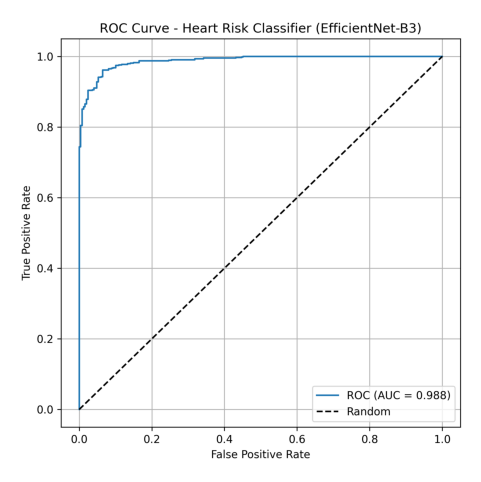

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3")
roc_path = OUTPUT_DIR / "roc_curve.png"

if roc_path.exists():
    print(f"Displaying ROC curve from {roc_path}")
    img = plt.imread(roc_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"Error: ROC curve not found at {roc_path}")
    print("Please ensure the evaluation cell was run successfully to generate the ROC curve.")

In [ ]:
import numpy as np
print("Class Distribution:")
print(f"Class 0 (Low Risk): {np.sum(y_train == 0)}")
print(f"Class 1 (High Risk): {np.sum(y_train == 1)}")
print(f"Imbalance Ratio: {np.sum(y_train == 1)/np.sum(y_train==0):.1f}")

Class Distribution:
Class 0 (Low Risk): 1228
Class 1 (High Risk): 2836
Imbalance Ratio: 2.3


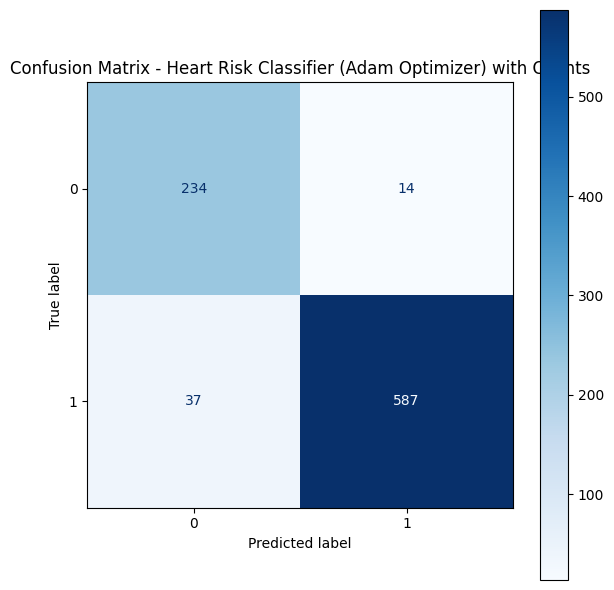

Detailed confusion matrix for Adam optimizer saved to /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/confusion_matrix_detailed.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np # Import numpy

OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3")
cm_adam_path = OUTPUT_DIR / "confusion_matrix.png"

# Assuming y_true and y_pred (for Adam optimizer) are available from previous execution
# If not, they would need to be reloaded/re-evaluated. For now, we'll assume they are.

y_true = np.load(OUTPUT_DIR / "y_true.npy")
y_prob = np.load(OUTPUT_DIR / "y_prob.npy")
y_pred = (y_prob >= 0.5).astype(int)

# Generate the confusion matrix with counts
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format='d') # Added values_format='d' for counts
plt.title("Confusion Matrix - Heart Risk Classifier (Adam Optimizer) with Counts")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_detailed.png", dpi=300)
plt.show()

print(f"Detailed confusion matrix for Adam optimizer saved to {OUTPUT_DIR / 'confusion_matrix_detailed.png'}")

In [ ]:
# 2. Calculate weight (1 line!)
pos_weight = torch.tensor([np.sum(y_train==0) / np.sum(y_train==1)]).to(DEVICE)
print(f"✅ Pos_weight applied: {pos_weight.item():.3f}")

# 3. Replace criterion line
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

✅ Pos_weight applied: 0.433


In [ ]:
 # @title
''' final evaluation of the best-performing multi-modal
 heart risk classifier on the unseen test dataset'''
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

# Correct OUTPUT_DIR to point to the actual directory where the model was saved
# The model was saved in cell 'kc7mqJnFwb2-' to /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3
OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Construct the checkpoint_path correctly by joining OUTPUT_DIR and the filename
checkpoint_path = OUTPUT_DIR / "best_model.pth"

# -------------------------------------------------
# Evaluate best model on test set (fixed torch.load)
# -------------------------------------------------

# If you are on PyTorch >= 2.6, explicitly set weights_only=False
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state"])

criterion = torch.nn.BCEWithLogitsLoss()

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_targets, all_probs = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb.float())

            total_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(yb.cpu().numpy())

    total_loss /= len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_targets, preds)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auc = float("nan")

    return total_loss, acc, auc, all_targets, all_probs

test_loss, test_acc, test_auc, y_true, y_prob = eval_epoch(
    model, test_loader, criterion
)
print(f"TEST | loss {test_loss:.4f}, acc {test_acc:.3f}, AUC {test_auc:.3f}")

np.save(OUTPUT_DIR / "y_true.npy", y_true)
np.save(OUTPUT_DIR / "y_prob.npy", y_prob)

# -----------------------------
# ROC curve
# -----------------------------
from sklearn.metrics import roc_curve  # [web:142]

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Risk Classifier (EfficientNet-B3)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=300)
plt.close()

# -----------------------------
# Confusion matrix
# -----------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # [web:137][web:143]

y_pred = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Heart Risk Classifier (EfficientNet-B3)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300)
plt.close()

print(f"Saved ROC curve and confusion matrix to {OUTPUT_DIR}")

TEST | loss 0.1905, acc 0.935, AUC 0.984
Saved ROC curve and confusion matrix to /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3


In [ ]:
'''FusionClassifier class, which is the neural network responsible
 for making the final heart risk
 prediction after the image and clinical features have been combined'''
class FusionClassifier(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1),   # <-- final prediction layer
        )

    def forward(self, x):
        logits = self.net(x)     # raw scores (logits)
        return logits.view(-1)


In [ ]:
'''a helper function named predict_proba. This function
 is designed to take a trained model (like our FusionClassifier)
 and a tensor of fused features (the combined image and clinical data),
and then return the predicted probabilities of heart risk.'''
def predict_proba(model, x_fused_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(x_fused_tensor.to(DEVICE))
        probs = torch.sigmoid(logits)
    return probs.cpu().numpy()#hese probabilities are moved back to the CPU and converted into a NumPy arra


In [ ]:
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

OUTPUT_DIR = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3")

# If y_true and y_prob are still in memory from the previous cell, you can skip loading.
# Otherwise, load them from the saved .npy files:
y_true = np.load(OUTPUT_DIR / "y_true.npy")
y_prob = np.load(OUTPUT_DIR / "y_prob.npy")

# Convert probabilities to binary predictions with threshold 0.5
y_pred = (y_prob >= 0.45).astype(int)

# Binary classification metrics (positive class = 1)
precision = precision_score(y_true, y_pred, pos_label=1)
recall    = recall_score(y_true, y_pred, pos_label=1)
f1        = f1_score(y_true, y_pred, pos_label=1)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

# Optional: full classification report (per class + averages)
print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=3))


Precision: 0.970
Recall:    0.941
F1-score:  0.955

Classification report:
              precision    recall  f1-score   support

           0      0.861     0.927     0.893       248
           1      0.970     0.941     0.955       624

    accuracy                          0.937       872
   macro avg      0.916     0.934     0.924       872
weighted avg      0.939     0.937     0.938       872



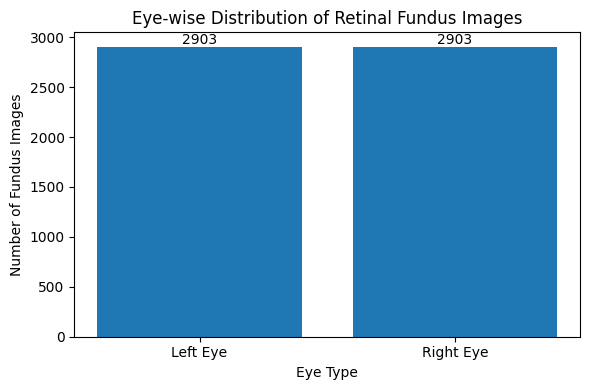

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/Data_Set_China/data_csv.csv')

# Count Left and Right eye images
eye_counts = data['eye'].value_counts().sort_index()

# Rename labels for paper clarity
eye_counts.index = ['Left Eye' if x == 'L' else 'Right Eye' for x in eye_counts.index]

# Plot bar graph
plt.figure(figsize=(6,4))
plt.bar(eye_counts.index, eye_counts.values)

plt.xlabel('Eye Type')
plt.ylabel('Number of Fundus Images')
plt.title('Eye-wise Distribution of Retinal Fundus Images')

# Show values on bars
for i, value in enumerate(eye_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
'''defines the predict_risk function, which is a utility function used to
make predictions (both probabilities and binary labels) from a trained heart risk model.'''
import torch
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def predict_risk(model, fused_features_np, threshold: float = 0.5):
    """
    fused_features_np: numpy array of shape (N, 1288) for N samples.
    Returns:
      probs  - heart risk probabilities in [0, 1]
      labels - binary predictions (0 = low risk, 1 = high risk)
    """
    model.eval()
    x = torch.from_numpy(fused_features_np.astype(np.float32)).to(DEVICE)

    with torch.no_grad():
        logits = model(x)              # shape (N,)
        probs = torch.sigmoid(logits)  # convert logits -> probability

    probs = probs.cpu().numpy()
    labels = (probs >= threshold).astype(int)
    return probs, labels


🚀 B3 Inference | Device: cuda
📏 B3 Features: 1536D, Clinical Features: 12D
⚠️  Trained model not found at specified path! Using randomly initialized classifier.
   Expected path: /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model.pth

🎯 B3 Heart Risk Predictor READY!
📁 Model: /content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model.pth


Saving 703982001_R.png to 703982001_R (3).png

🔬 Analyzing: 703982001_R (3).png


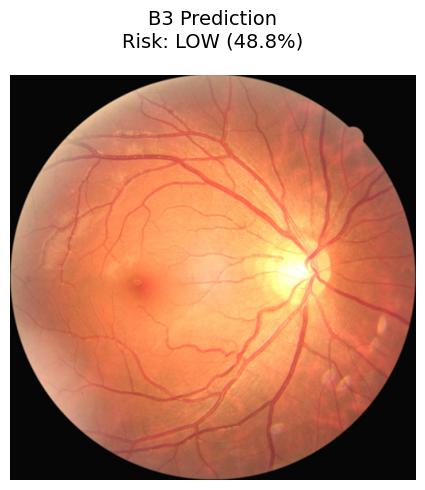


🎯 FINAL B3 RESULT:
Risk probability: 0.488 (48.8%)
Class (0=low, 1=high): 0
💾 Saved: /content/drive/MyDrive/heart_risk_results/b3_result_703982001_R (3).png


In [ ]:
from google.colab import files
import cv2, torch, torch.nn as nn
import numpy as np
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from pathlib import Path
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 384  # Match your B3 preprocessing
IMAGE_FEAT_DIM = 1536  # EfficientNet-B3 ✓
CLINICAL_FEAT_DIM = 12 # Number of clinical features used in FusionClassifier
FUSED_DIM = IMAGE_FEAT_DIM + CLINICAL_FEAT_DIM

# Paths
CHECKPOINT_PATH = Path("/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model.pth")
OUTPUT_DIR = Path("/content/drive/MyDrive/heart_risk_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"🚀 B3 Inference | Device: {DEVICE}")
print(f"📏 B3 Features: {IMAGE_FEAT_DIM}D, Clinical Features: {CLINICAL_FEAT_DIM}D")

# ----- Image preprocessing (COMPLETE IMPLEMENTATION) -----
def crop_fundus_circle(img, padding=10):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(gray_blur, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(mask)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    x0 = max(x - padding, 0); y0 = max(y - padding, 0)
    x1 = min(x + w + padding, img.shape[1])
    y1 = min(y + h + padding, img.shape[0])
    return img[y0:y1, x0:x1]

image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ----- B3 Feature Extractor (COMPLETE) -----
def build_img_feature_extractor():
    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
    model = efficientnet_b3(weights=weights)
    model.classifier = nn.Identity()  # Remove head → 1536D features
    model.eval()
    return model.to(DEVICE)

img_feature_extractor = build_img_feature_extractor()

def extract_image_feature_single(img_path: str) -> np.ndarray:
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    img = crop_fundus_circle(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = image_transform(img).unsqueeze(0).to(DEVICE)  # (1,3,384,384)

    with torch.no_grad():
        feat = img_feature_extractor(img_tensor)  # (1, 1536)

    return feat.cpu().numpy().reshape(-1)  # (1536,)

# ----- FusionClassifier definition (copied from RNIefPhz6Hbm) -----
class FusionClassifier(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1),         # binary classification
        )

    def forward(self, x):
        logits = self.net(x)
        return logits.view(-1)


# ----- Model Loading (FIXED to load FusionClassifier) -----
def load_fusion_classifier():
    """Load trained FusionClassifier state_dict safely"""
    classifier = FusionClassifier(FUSED_DIM).to(DEVICE)

    if CHECKPOINT_PATH.exists():
        print("✅ Loading B3 trained fusion model...")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
        classifier.load_state_dict(checkpoint["model_state"])
        print("   ✓ Model state loaded successfully.")
    else:
        print("⚠️  Trained model not found at specified path! Using randomly initialized classifier.")
        print(f"   Expected path: {CHECKPOINT_PATH}")

    classifier.eval()
    return classifier

# Load classifier
classifier = load_fusion_classifier()

# ----- Prediction Function (B3 Ready with dummy clinical features) -----
def predict_risk_from_image_path(img_path: str, threshold=0.5):
    img_feat = extract_image_feature_single(img_path)      # (1536,)

    # Create dummy clinical features (e.g., zeros or means from training data)
    # For simplicity, using zeros here. In a real-world scenario, you'd use
    # actual patient clinical data or population means.
    dummy_clin_feat = np.zeros(CLINICAL_FEAT_DIM, dtype=np.float32)

    # Fuse image and dummy clinical features
    fused_feat = np.concatenate([img_feat, dummy_clin_feat], axis=0)

    x = torch.from_numpy(fused_feat[None, :].astype(np.float32)).to(DEVICE)  # (1, FUSED_DIM)

    with torch.no_grad():
        logits = classifier(x)                          # (1,)
        probs = torch.sigmoid(logits).cpu().numpy()     # (1,)

    label = int(probs[0] >= threshold)
    return float(probs[0]), label

# ----- Test & Visualize -----
print("\n🎯 B3 Heart Risk Predictor READY!")
print(f"📁 Model: {CHECKPOINT_PATH}")

# Upload and predict
uploaded = files.upload()
img_filename = list(uploaded.keys())[0]

print(f"\n🔬 Analyzing: {img_filename}")
prob, label = predict_risk_from_image_path(img_filename)

# Visualize result
img = cv2.imread(img_filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5)) # Adjusted figure size for a single plot
plt.imshow(img_rgb)
plt.title(f"B3 Prediction\nRisk: {'HIGH' if label else 'LOW'} ({prob:.1%})",
          fontsize=14, pad=20)
plt.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"b3_result_{Path(img_filename).stem}.png", dpi=300)
plt.show()


print(f"\n🎯 FINAL B3 RESULT:")
print(f"Risk probability: {prob:.3f} ({prob:.1%})")
print(f"Class (0=low, 1=high): {label}")
print(f"💾 Saved: {OUTPUT_DIR / f'b3_result_{Path(img_filename).stem}.png'}")

In [ ]:
# This cell is no longer needed as the drive is already mounted by cell gNTqBnPh0BsK.

In [ ]:
# Find ALL your best models
!find /content/drive/MyDrive -name "*best*.pth" -o -name "*model*.pth" | head -20


/content/drive/MyDrive/Data_Set_China/heart_risk_results/best_model.pth
/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model_adamw.pth
/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model_lion.pth
/content/drive/MyDrive/Data_Set_China/heart_risk_results/B3/best_model.pth
/content/drive/MyDrive/Data_Set_China/B3/heart_risk_results/best_model.pth
